   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender    Education           City EmploymentType Loan Status
0   56  48353.0       31258        675.0               20  Female  High School        Houston     Unemployed    Approved
1   69  57462.0       23262        586.0                6    Male  High School  San Francisco  Self-Employed    Approved
2   46  44219.0       26530        781.0               26    Male          PhD        Houston  Self-Employed    Rejected
3   32  56307.0       11531        549.0               11    Male          NaN       New York     Unemployed    Approved
4   60  37034.0       27871        500.0               19  Female  High School        Chicago     Unemployed    Approved
5   25  47886.0       18106        835.0               13    Male      Masters       New York       Salaried    Rejected
6   38  54748.0       25374        760.0                9  Female  High School       New York  Self-Employed    Rejected
7   56      NaN        6279     

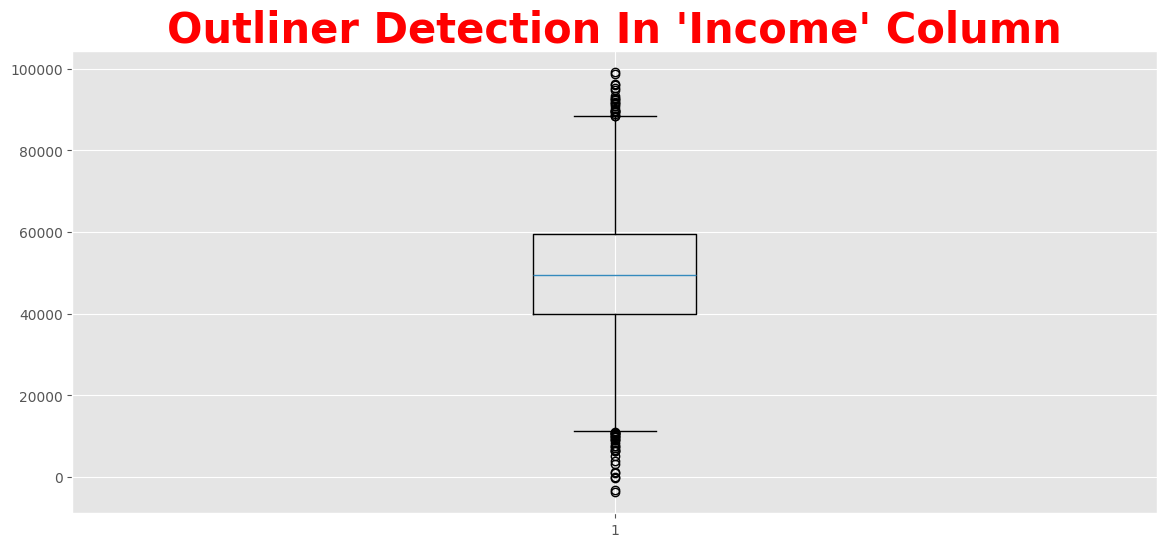

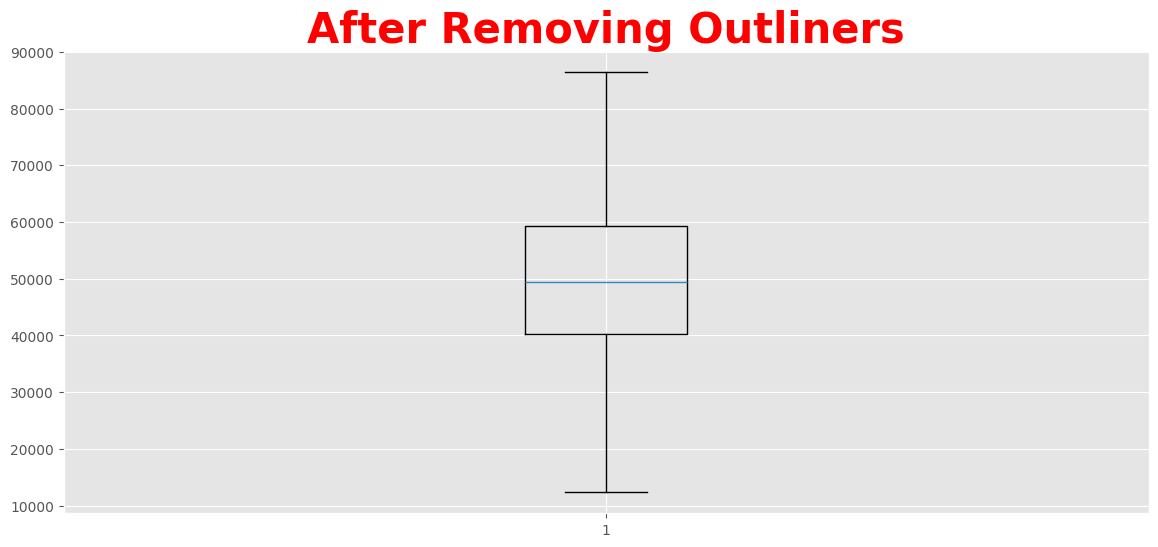

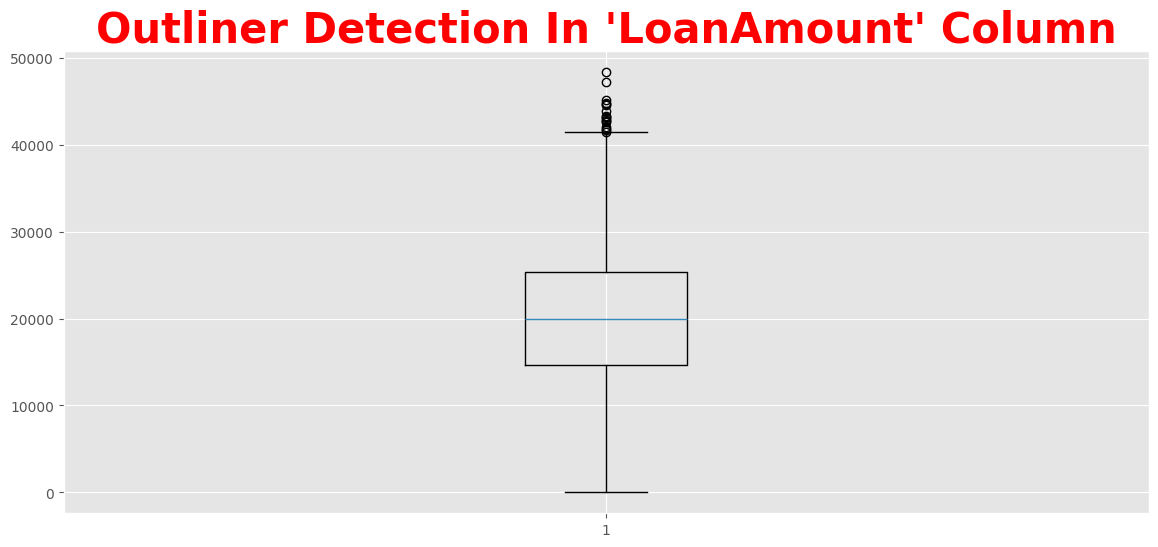

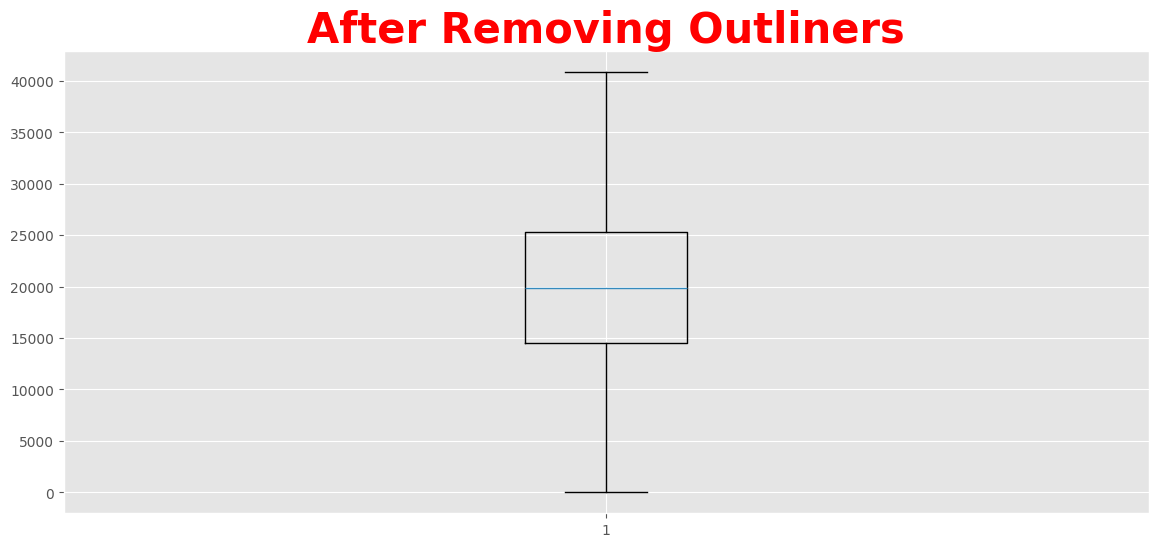

    Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  Education  City  EmploymentType Loan Status
0    56  48353.0       31258        675.0               20       0          1     1               2    Approved
1    69  57462.0       23262        586.0                6       1          1     3               1    Approved
2    46  44219.0       26530        781.0               26       1          3     1               1    Rejected
3    32  56307.0       11531        549.0               11       1          3     2               2    Approved
4    60  37034.0       27871        500.0               19       0          1     0               2    Approved
5    25  47886.0       18106        835.0               13       1          2     2               0    Rejected
6    38  54748.0       25374        760.0                9       0          1     2               1    Rejected
7    56  49488.0        6279        599.0               22       1          3     2               2    A

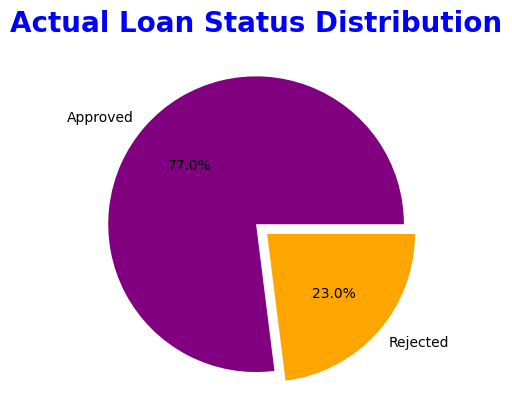

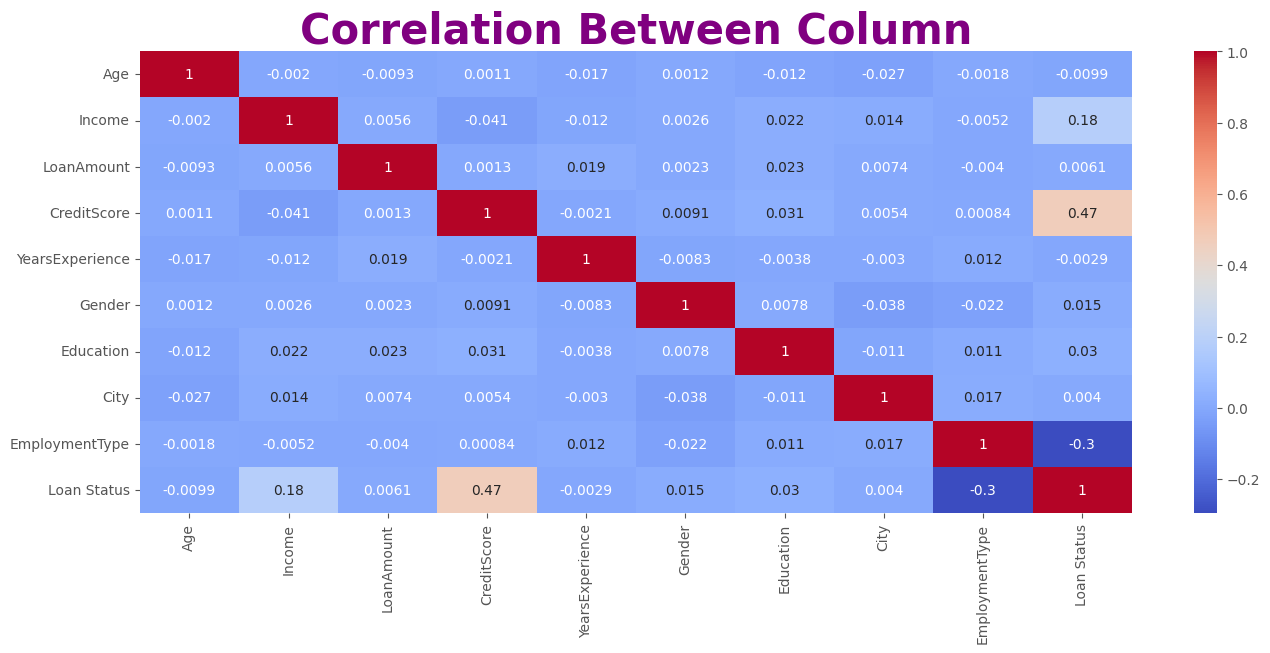



CVS OF Decision Tree Classifier [0.96319018 0.96319018 0.97341513 0.96008188 0.97236438]
Average CVS OF Decision Tree Classifier 0.9664483530192379


Train Score 0.9726342710997442
Test Score 0.9713701431492843


Accuracy Of Decision Tree Classifier
0.9713701431492843


Confusion Matrics
[[746   8]
 [ 20 204]]


Classification Report
              precision    recall  f1-score   support

    Approved       0.97      0.99      0.98       754
    Rejected       0.96      0.91      0.94       224

    accuracy                           0.97       978
   macro avg       0.97      0.95      0.96       978
weighted avg       0.97      0.97      0.97       978



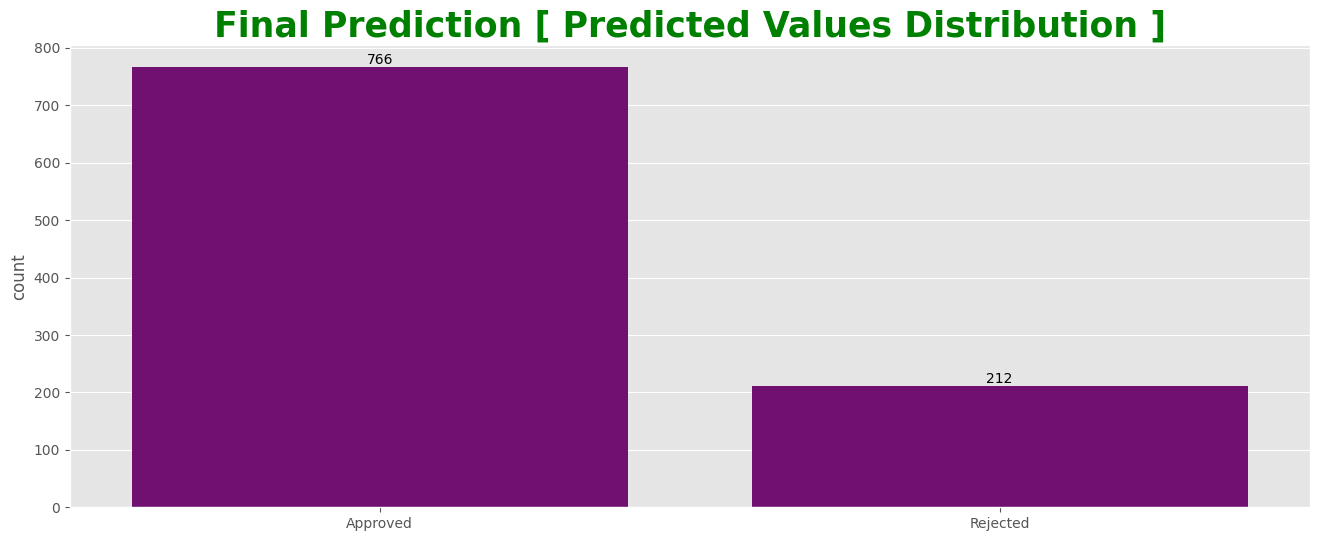

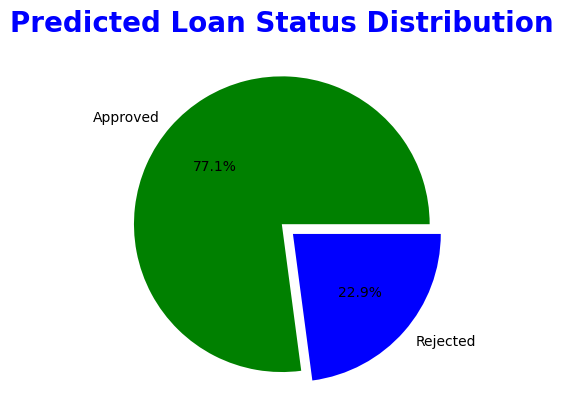

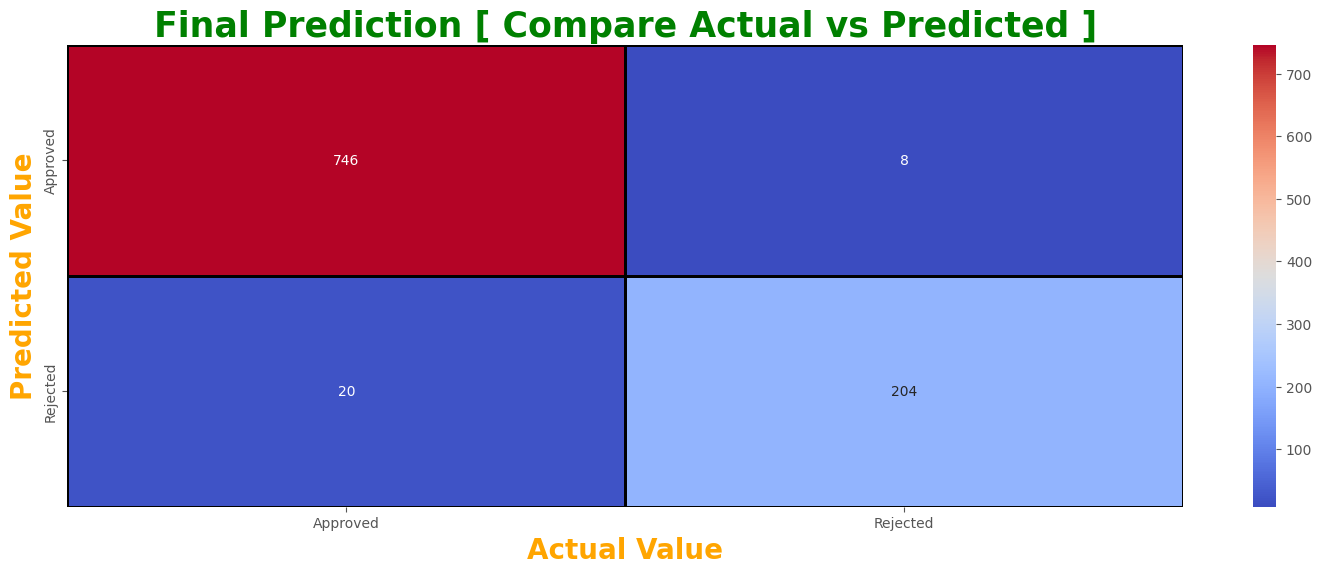

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use('ggplot')

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv('loan_risk_prediction_dataset.csv')
print(JP.head(10))

# print(JP.isna().sum())
# JP=JP[JP.duplicated()]
# print(JP)

JP[['Income','CreditScore']]=JP[['Income','CreditScore']].fillna(JP[['Income','CreditScore']].median())
JP['Education']=JP['Education'].ffill()

# print(JP['LoanAmount'].sort_values().head(30))
JP=JP.query(" LoanAmount > 0 ")
# print(JP['LoanAmount'].sort_values().head(20))

print(JP.head(20))

plt.figure(figsize=(14,6))
plt.boxplot(JP['Income'])
plt.title("Outliner Detection In 'Income' Column",fontsize=30,fontweight='bold',color='red')
plt.show()

Q1=JP['Income'].quantile(0.25)
Q3=JP['Income'].quantile(0.75)

IQR=Q3-Q1

lower=Q1 - 1.45 * IQR
upper=Q3 + 1.4 * IQR

JP=JP[ (JP['Income'] > lower) & (JP['Income'] < upper) ]

plt.figure(figsize=(14,6))
plt.boxplot(JP['Income'])
plt.title("After Removing Outliners",fontsize=30,fontweight='bold',color='red')
plt.show()


plt.figure(figsize=(14,6))
plt.boxplot(JP['LoanAmount'])
plt.title("Outliner Detection In 'LoanAmount' Column",fontsize=30,fontweight='bold',color='red')
plt.show()

Q1=JP['LoanAmount'].quantile(0.25)
Q3=JP['LoanAmount'].quantile(0.75)

IQR=Q3-Q1

lower=Q1 - 1.45 * IQR
upper=Q3 + 1.45 * IQR

JP=JP[ (JP['LoanAmount'] > lower) & (JP['LoanAmount'] < upper) ]

plt.figure(figsize=(14,6))
plt.boxplot(JP['LoanAmount'])
plt.title("After Removing Outliners",fontsize=30,fontweight='bold',color='red')
plt.show()


from sklearn.preprocessing import LabelEncoder

JP['Gender']=LabelEncoder().fit_transform(JP['Gender'])
JP['Education']=LabelEncoder().fit_transform(JP['Education'])
JP['EmploymentType']=LabelEncoder().fit_transform(JP['EmploymentType'])
JP['City']=LabelEncoder().fit_transform(JP['City'])

print(JP.head(20))


plt.pie(JP['Loan Status'].value_counts(),labels=JP['Loan Status'].value_counts().index,autopct='%1.1f%%',colors=['purple','orange'],explode=[0,0.1])
plt.title("Actual Loan Status Distribution",fontsize=20,fontweight='bold',color='blue')
plt.show()


hgj=JP[['Age','Income','LoanAmount','CreditScore','YearsExperience','Gender','Education','City','EmploymentType','Loan Status']]

hgj['Loan Status']=LabelEncoder().fit_transform(hgj['Loan Status'])
plt.figure(figsize=(16,6))
sns.heatmap(hgj.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Between Column",fontsize=30,fontweight='bold',color='purple')
plt.show()


x=JP[['Age','Income','LoanAmount','CreditScore','YearsExperience','Gender','Education','City','EmploymentType']]
y=JP['Loan Status']


from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

from sklearn.model_selection  import cross_val_score
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=5,random_state=67)

score=cross_val_score(model,x_scaled,y,cv=5,scoring='accuracy')
print("\n")
print("CVS OF Decision Tree Classifier",score)
print("Average CVS OF Decision Tree Classifier",score.mean())

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=36)


# model=LogisticRegression(max_iter=1000)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


# from sklearn.ensemble import RandomForestClassifier

# model=RandomForestClassifier(n_estimators=100,random_state=67)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=5,random_state=67)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)



Train_Score=model.score(x_train,y_train)
Test_Score=model.score(x_test,y_test)

print("\n")
print("Train Score",Train_Score)
print("Test Score",Test_Score)

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

print("\n")
print("Accuracy Of Decision Tree Classifier")
print(accuracy_score(y_test,Y_Pred))

print("\n")
print("Confusion Matrics")
CM=confusion_matrix(y_test,Y_Pred)
print(CM)

print("\n")
print("Classification Report")
print(classification_report(y_test,Y_Pred))


plt.figure(figsize=(16,6))
plot=sns.countplot(x=Y_Pred,color='purple')
for container in plot.containers:
    plot.bar_label(container)
plt.title("Final Prediction [ Predicted Values Distribution ]",fontsize=25,fontweight='bold',color='Green')
plt.show()

plt.pie(y_test.value_counts(),labels=y_test.value_counts().index,autopct='%1.1f%%',colors=['green','blue'],explode=[0,0.1])
plt.title("Predicted Loan Status Distribution",fontsize=20,fontweight='bold',color='blue')
plt.show()

plt.figure(figsize=(18,6))
sns.heatmap(CM,annot=True,fmt='d',cmap='coolwarm',xticklabels=["Approved","Rejected",],yticklabels=["Approved","Rejected"],linewidths=1,linecolor='black')
plt.title("Final Prediction [ Compare Actual vs Predicted ]",fontsize=25,fontweight='bold',color='Green')
plt.xlabel("Actual Value",fontsize=20,color='orange',fontweight='bold')
plt.ylabel("Predicted Value",fontsize=20,color='orange',fontweight='bold')
plt.show()